<h1 style="color: red; font-size: 48px; text-align: center;">Multimodal Manufacturing Quality Intelligence</h1>
<h3 style="color: #555; text-align: center;">Computer Vision &middot; RAG &middot; Agentic Reporting for Industry 4.0</h3>

<center>
    <img src="https://media.giphy.com/media/J1Lfq5xvMZCnnNudyL/giphy.gif" alt="robotic arm quality inspection" height="260" width="520">
</center>


# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    This project is an <b>end-to-end multimodal AI system for automated manufacturing quality inspection</b>.
    It fuses <b>YOLOv8 defect detection</b>, <b>Vision Transformer (ViT) severity grading</b>,
    <b>LlamaIndex + Qdrant RAG</b> over product-specification documents, and a
    <b>LangGraph multi-step quality agent</b> that drafts <b>ISO&nbsp;9001 non-conformance reports</b>
    and triggers <b>ERP quarantine workflows</b> &mdash; all behind a single <b>FastAPI</b> endpoint.
</div>

# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Manual visual inspection on a production line is slow, subjective, and hard to audit.
    Inspectors must spot the defect, judge its severity against a written specification, decide a disposition
    (pass / rework / quarantine / scrap), document it for compliance, and update the ERP system &mdash; all in seconds.
    This project automates that full loop with a reproducible, deterministic-fallback pipeline so a decision is
    <b>always</b> produced, even when heavy models or external services are unavailable.
</div>

# 🔭 System Components

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong><code>vision.detector</code></strong>: YOLOv8 (Ultralytics) defect detector with an OpenCV Canny-edge fallback. Emits a defect type, confidence, and bounding box for each finding.</p></li>
<li><p><strong><code>vision.severity</code></strong>: Vision Transformer severity grader (Critical / Major / Minor) with a morphology-based fallback (edge density &times; intensity std).</p></li>
<li><p><strong><code>vision.gradcam</code></strong>: Grad-CAM overlay generator that paints a JET heatmap over each detected region for explainability.</p></li>
<li><p><strong><code>rag.ingestion</code> / <code>rag.retrieval</code></strong>: LlamaIndex + Qdrant ingestion and retrieval over product-specification PDFs, with a keyword-scoring JSON fallback.</p></li>
<li><p><strong><code>agent.quality_agent</code></strong>: A five-node LangGraph state machine (retrieve &rarr; classify &rarr; report &rarr; ERP) driven by Llama&nbsp;3.1 via Ollama, with a rule-engine fallback.</p></li>
<li><p><strong><code>agent.iso_report</code></strong>: ISO&nbsp;9001 non-conformance report writer (Markdown + optional PDF via reportlab).</p></li>
<li><p><strong><code>agent.erp_client</code></strong>: ERP webhook poster with a JSONL outbox fallback for the audit trail.</p></li>
<li><p><strong><code>active_learning</code></strong>: Operator-feedback store and a retraining trigger that schedules YOLOv8 fine-tunes tracked by MLflow.</p></li>
<li><p><strong><code>api.main</code></strong>: FastAPI REST layer exposing <code>/inspect</code>, <code>/feedback</code>, and <code>/retrain/status</code>.</p></li>
</ol>
<p>
Every component <b>degrades gracefully</b> &mdash; the pipeline runs even without <code>ultralytics</code>,
<code>transformers</code>, Qdrant, or Ollama installed, returning deterministic results so the system always reaches a decision.
</p>
</div>

# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Detect surface defects and localise them with bounding boxes.</li>
        <li>Grade each defect's severity and explain it visually with Grad-CAM.</li>
        <li>Ground every disposition in the relevant product specification via RAG.</li>
        <li>Generate an auditable ISO&nbsp;9001 report and push the WIP status to the ERP.</li>
        <li>Close the loop with operator feedback that drives scheduled model retraining.</li>
    </ul>
</div>


# Importing Libraries


In [1]:
import os
import sys
import json
import logging
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

from rich.console import Console
from rich.table import Table
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("src").setLevel(logging.ERROR)
plt.style.use("ggplot")
console = Console()

# Project Setup


In [2]:
# Locate the project root (the folder that contains `src/`) and make it importable.
# On Kaggle the repo is not checked out, so we clone it from GitHub first - no dataset needed.
import subprocess

REPO_URL = "https://github.com/rohitndev/Multimodal-Manufacturing-Quality-Intelligence-with-Agentic-Reporting.git"

def find_project_root(start: Path):
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "requirements.txt").exists():
            return p
    return None

PROJECT_ROOT = find_project_root(Path.cwd())

if PROJECT_ROOT is None:
    base = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path.cwd()
    clone_dir = base / "mmqi"
    if not (clone_dir / "src").is_dir():
        console.print(f"[yellow]src/ not found - cloning project from GitHub...[/yellow]")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)], check=True)
    PROJECT_ROOT = clone_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

console.rule("[bold blue]Project Root[/bold blue]")
console.print(f"[bold]Working directory:[/bold] {PROJECT_ROOT}")

────────────────────────────────────────────────── Project Root ───────────────────────────────────────────────────

Working directory: D:\rohit\Multimodal Manufacturing Quality Intelligence with Agentic Reporting

## Technology Stack


In [3]:
stack = [
    ("Object Detection",      "YOLOv8 (Ultralytics)",          "Defect detection + bounding box"),
    ("Severity Grading",      "Vision Transformer (HF)",       "Critical / Major / Minor"),
    ("Explainability",        "Grad-CAM",                      "Heatmaps over defect regions"),
    ("Spec RAG Store",        "LlamaIndex + Qdrant",           "Product-spec retrieval"),
    ("Local LLM",             "Ollama + Llama 3.1 (8B)",       "Decision reasoning"),
    ("Agentic Layer",         "LangGraph",                     "Multi-step quality agent"),
    ("Reporting",             "ISO 9001 NCR (MD/PDF)",         "Non-conformance documentation"),
    ("API Layer",             "FastAPI",                       "REST inspection endpoint"),
    ("Model Tracking",        "MLflow + DVC",                  "Fine-tune runs / model registry"),
    ("Deployment",            "Docker + Terraform (AWS/GCP)",  "Cloud-agnostic delivery"),
]

table = Table(show_header=True, header_style="bold magenta")
table.add_column("Layer"); table.add_column("Technology"); table.add_column("Purpose")
for row in stack:
    table.add_row(*row)
console.print(table)

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer            ┃ Technology                   ┃ Purpose                         ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Object Detection │ YOLOv8 (Ultralytics)         │ Defect detection + bounding box │
│ Severity Grading │ Vision Transformer (HF)      │ Critical / Major / Minor        │
│ Explainability   │ Grad-CAM                     │ Heatmaps over defect regions    │
│ Spec RAG Store   │ LlamaIndex + Qdrant          │ Product-spec retrieval          │
│ Local LLM        │ Ollama + Llama 3.1 (8B)      │ Decision reasoning              │
│ Agentic Layer    │ LangGraph                    │ Multi-step quality agent        │
│ Reporting        │ ISO 9001 NCR (MD/PDF)        │ Non-conformance documentation   │
│ API Layer        │ FastAPI                      │ REST inspection endpoint        │
│ Model Tracking   │ MLflow + DVC                 │ Fine-tune runs / model registry │
│ Deployment       │ Docker + Terraform (AWS/GCP) │ Cloud-agnostic delivery         │
└──────────────────┴──────────────────────────────┴─────────────────────────────────┘

## Load Sample Inspection Image


Image path : D:\rohit\Multimodal Manufacturing Quality Intelligence with Agentic Reporting\data\sample_images\test_panel.png
Image shape: (480, 640, 3)


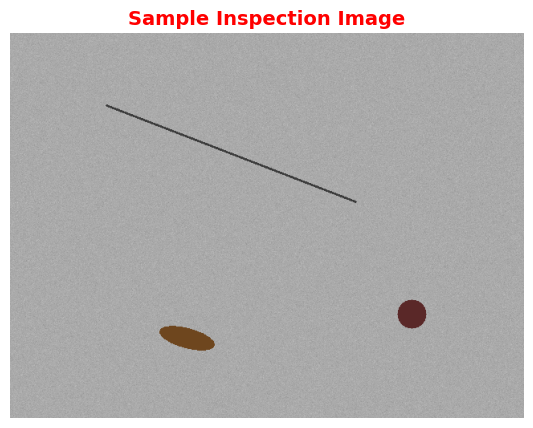

In [4]:
IMAGE_PATH = PROJECT_ROOT / "data" / "sample_images" / "test_panel.png"
image = cv2.imread(str(IMAGE_PATH))

if image is None:
    # No sample image on disk (e.g. dataset not attached) - synthesise a metal panel with defects.
    rng = np.random.default_rng(42)
    image = np.full((480, 640, 3), 170, np.uint8)
    noise = rng.normal(0, 6, (480, 640, 1)).astype(np.int16)
    image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    cv2.line(image, (120, 90), (430, 210), (60, 60, 60), 2)                       # scratch
    cv2.circle(image, (500, 350), 18, (40, 40, 90), -1)                           # dent
    cv2.ellipse(image, (220, 380), (35, 12), 15, 0, 360, (30, 70, 110), -1)       # stain
    IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(IMAGE_PATH), image)
    print("Sample image not found - generated a synthetic test panel instead.")

print("Image path :", IMAGE_PATH)
print("Image shape:", image.shape)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Sample Inspection Image", fontsize=14, fontweight="bold", color="red")
plt.axis("off")
plt.show()

# 🔍 Vision Pipeline

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The vision pipeline turns a raw product image into a structured list of defects.
    It runs <b>detection</b> (where &amp; what), <b>severity grading</b> (how bad), and
    <b>Grad-CAM explainability</b> (why) &mdash; each stage with a deterministic fallback so inference never fails.
</div>

## 📊 Pipeline Stages

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><b>YOLOv8 Detection</b> &rarr; defect type, confidence, bounding box.</li>
        <li><b>ViT Severity</b> &rarr; Critical / Major / Minor with a probability distribution.</li>
        <li><b>Grad-CAM Overlay</b> &rarr; a JET heatmap attached to the ISO report.</li>
    </ul>
</div>

## 📈 Inspection Steps

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong>Detect defects:</strong> run <code>DefectDetector</code> over the panel image to localise candidate defects.</p></li>
<li><p><strong>Grade severity:</strong> crop each detection and pass it to the <code>SeverityClassifier</code>.</p></li>
<li><p><strong>Explain visually:</strong> render a Grad-CAM overlay so an inspector can see what the model focused on.</p></li>
</ol>
</div>


## YOLOv8 Defect Detection


In [5]:
from src.vision.detector import DefectDetector

detector = DefectDetector()                  # falls back to OpenCV edges if Ultralytics is absent
detections = detector.detect(image)

console.rule("[bold blue]Detections[/bold blue]")
console.print(f"[bold green]{len(detections)} defect(s) found[/bold green]")
for d in detections:
    console.print(f"  - {d.defect_type:8s} conf={d.confidence:.2f} bbox={d.bbox}")

─────────────────────────────────────────────────── Detections ────────────────────────────────────────────────────

3 defect(s) found

- dent     conf=0.95 bbox=[482, 332, 519, 369]

- stain    conf=0.91 bbox=[186, 364, 255, 397]

- scratch  conf=0.73 bbox=[119, 89, 432, 212]

## Vision Transformer Severity Grading


In [6]:
from src.vision.severity import SeverityClassifier

severity = SeverityClassifier()              # falls back to a morphology grader if ViT is absent

console.rule("[bold blue]Severity Grading[/bold blue]")
for d in detections[:5]:
    res = severity.classify(image, d.bbox)
    console.print(f"  {d.defect_type:8s} -> [bold]{res.level:8s}[/bold] (score={res.score:.2f})  {res.probabilities}")

──────────────────────────────────────────────── Severity Grading ─────────────────────────────────────────────────

dent     -> Major    (score=0.42)  {'Critical': 0.0711, 'Major': 0.6505, 'Minor': 0.2784}

stain    -> Major    (score=0.37)  {'Critical': 0.0391, 'Major': 0.5709, 'Minor': 0.3901}

scratch  -> Minor    (score=0.12)  {'Critical': 0.001, 'Major': 0.1377, 'Minor': 0.8613}

## Grad-CAM Explainability + Full Pipeline


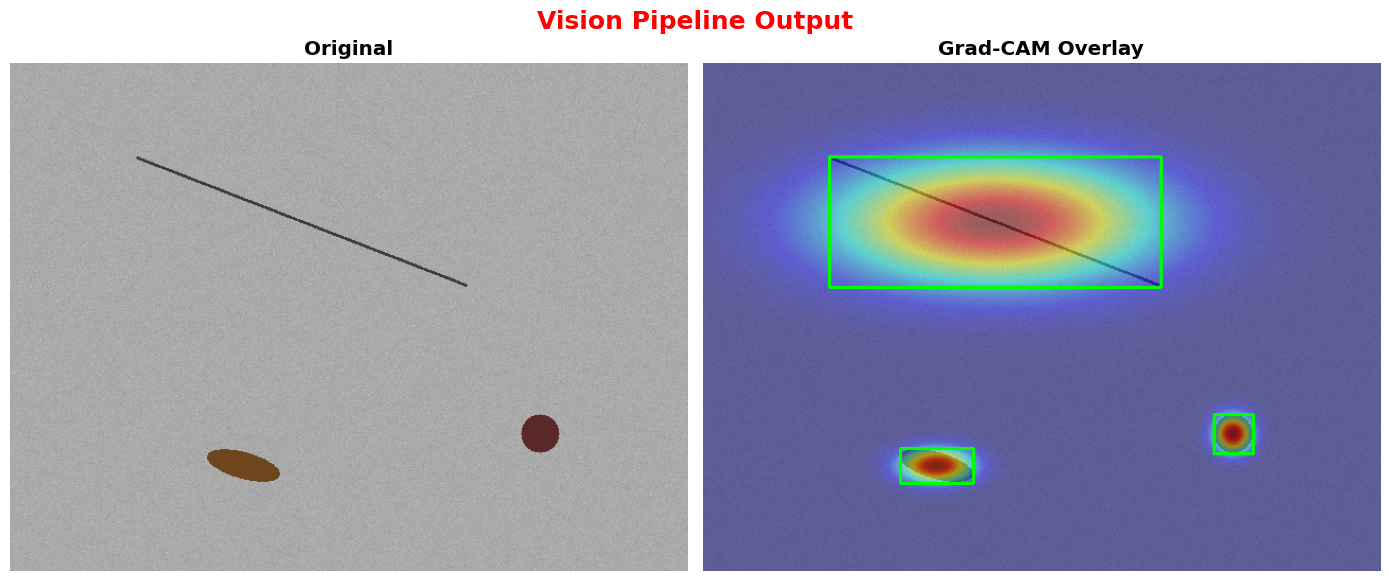

[
  {
    "defect_id": "INSP-DEMO-D001",
    "defect_type": "dent",
    "confidence": 0.95,
    "bbox": [
      482,
      332,
      519,
      369
    ],
    "severity": "Major",
    "severity_score": 0.422,
    "severity_probs": {
      "Critical": 0.0711,
      "Major": 0.6505,
      "Minor": 0.2784
    }
  },
  {
    "defect_id": "INSP-DEMO-D002",
    "defect_type": "stain",
    "confidence": 0.9081,
    "bbox": [
      186,
      364,
      255,
      397
    ],
    "severity": "Major",
    "severity_score": 0.3685,
    "severity_probs": {
      "Critical": 0.0391,
      "Major": 0.5709,
      "Minor": 0.3901
    }
  },
  {
    "defect_id": "INSP-DEMO-D003",
    "defect_type": "scratch",
    "confidence": 0.7254,
    "bbox": [
      119,
      89,
      432,
      212
    ],
    "severity": "Minor",
    "severity_score": 0.1155,
    "severity_probs": {
      "Critical": 0.001,
      "Major": 0.1377,
      "Minor": 0.8613
    }
  }
]


In [7]:
from src.vision.pipeline import VisionPipeline
from src.vision.gradcam import gradcam_overlay

pipeline = VisionPipeline()
result = pipeline.run(image, image_id="INSP-DEMO")
findings = [f.to_dict() for f in result.findings]

overlay = gradcam_overlay(image, [f["bbox"] for f in findings]) if findings else image
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));   ax[0].set_title("Original", fontweight="bold");          ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); ax[1].set_title("Grad-CAM Overlay", fontweight="bold");  ax[1].axis("off")
plt.suptitle("Vision Pipeline Output", fontsize=18, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

print(json.dumps(findings, indent=2))

# 🧩 RAG Pipeline over Product Specifications

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    A disposition decision is only defensible if it cites the <b>product specification</b>.
    This layer ingests spec documents into a <b>Qdrant</b> vector store via <b>LlamaIndex</b>,
    then retrieves the tolerance snippets most relevant to the detected defect &mdash;
    falling back to keyword scoring over a JSON corpus when the vector store is unavailable.
</div>

## 🔧 Key Steps

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><b>Ingest</b> the spec PDFs/TXT/MD into the <code>product_specs</code> collection.</li>
        <li><b>Embed</b> with <code>sentence-transformers/all-MiniLM-L6-v2</code>.</li>
        <li><b>Retrieve</b> the top-k tolerance snippets for the worst defect, with sources.</li>
    </ul>
</div>


## LlamaIndex Ingestion + Spec Retrieval


In [8]:
from src.rag.ingestion import SpecIngestion
from src.rag.retrieval import SpecRetriever

n = SpecIngestion(specs_dir=str(PROJECT_ROOT / "data" / "sample_specs")).ingest()
console.print(f"[bold]Ingested[/bold] {n} spec document(s)/chunk(s)")

retriever = SpecRetriever()
defect_type = findings[0]["defect_type"] if findings else "scratch"
ctx = retriever.retrieve(defect_type, product="Metal Panel")

console.rule(f"[bold blue]Spec Context for '{defect_type}'[/bold blue]")
print((ctx.text or "(no snippet retrieved)")[:600])
console.print(f"[bold]Sources:[/bold] {ctx.sources}")

Ingested 5 spec document(s)/chunk(s)

───────────────────────────────────────────── Spec Context for 'dent' ─────────────────────────────────────────────

2.3 Scratches shorter than 1.0 mm are MINOR and acceptable up to 3 per panel. 3. Structural Defects
3.1 Any crack visible at 1× magnification is CRITICAL — quarantine immediately. 3.2 Voids exceeding 2.0 mm² in area are MAJOR. 3.3 Dents deeper than 0.5 mm or wider than 6.0 mm are MAJOR. Smaller dents
    are MINOR if outside the visible cosmetic zone. 4.
---
METAL PANEL — PRODUCT SPECIFICATION (MP-1024)

1. Scope
This specification defines acceptance criteria for cold-rolled metal panels
supplied to assembly line A3. 2. Surface Finish
2.1 Scratches longer than 5.0 mm or wider than 0.3 mm are C


Sources: ['spec_metal_panel.txt', 'spec_metal_panel.txt', 'spec_pcb_board.txt']

# 🤖 LangGraph Quality Agent

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The agent fuses the <b>defect findings</b> with the <b>retrieved specification</b>, asks Llama&nbsp;3.1
    for a structured disposition, writes an <b>ISO&nbsp;9001 non-conformance report</b>, and posts the
    WIP status to the ERP. When LangGraph or Ollama are unavailable, the same nodes run sequentially via a rule engine.
</div>

## ⚙️ Agent State Machine

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><code>retrieve_spec</code> &rarr; fetch the most relevant spec snippets for the worst defect.</li>
        <li><code>classify_decision</code> &rarr; PASS / REWORK / QUARANTINE / FAIL + rationale.</li>
        <li><code>generate_report</code> &rarr; render the ISO&nbsp;9001 NCR (Markdown + optional PDF).</li>
        <li><code>call_erp</code> &rarr; post the WIP status or queue it to the outbox.</li>
    </ul>
</div>


## Run the Agent


In [9]:
from src.agent.quality_agent import QualityAgent
from src.agent.iso_report import ISO9001ReportGenerator
from src.agent.erp_client import ERPClient

agent = QualityAgent(
    retriever=SpecRetriever(),
    report_generator=ISO9001ReportGenerator(output_dir=str(PROJECT_ROOT / "reports")),
    erp_client=ERPClient(),
)
decision = agent.run(inspection_id="INSP-DEMO", findings=findings, product="Metal Panel")

console.rule("[bold blue]Agent Decision[/bold blue]")
console.print(f"[bold]Decision :[/bold] [bold red]{decision.decision}[/bold red]")
console.print(f"[bold]Rationale:[/bold] {decision.rationale}")
console.print(f"[bold]Report   :[/bold] {decision.report.get('markdown_path')}")
console.print(f"[bold]ERP      :[/bold] {decision.erp_response.get('transport')}")

───────────────────────────────────────────────── Agent Decision ──────────────────────────────────────────────────

Decision : QUARANTINE

Rationale: Worst defect INSP-DEMO-D001 graded Major (score=0.42); per spec tolerance → QUARANTINE.

Report   : D:\rohit\Multimodal Manufacturing Quality Intelligence with Agentic 
Reporting\reports\NCR-20260612-104423.md

ERP      : outbox

## Generated ISO 9001 Non-Conformance Report


In [10]:
from IPython.display import Markdown, display

md_path = decision.report.get("markdown_path")
if md_path and Path(md_path).exists():
    display(Markdown(Path(md_path).read_text(encoding="utf-8")))
else:
    print("No report generated (no defects above threshold).")

# ISO 9001 Non-Conformance Report

**Report ID:** NCR-20260612-104423
**Generated:** 2026-06-12T10:44:23Z
**Inspection ID:** INSP-DEMO
**Product:** Metal Panel

## 1. Defect Summary

| # | Defect ID | Type | Severity | Confidence | Bounding Box |
|---|-----------|------|----------|------------|--------------|
| 1 | INSP-DEMO-D001 | dent | Major | 0.95 | [482, 332, 519, 369] |
| 2 | INSP-DEMO-D002 | stain | Major | 0.91 | [186, 364, 255, 397] |
| 3 | INSP-DEMO-D003 | scratch | Minor | 0.73 | [119, 89, 432, 212] |

## 2. Specification Reference

2.3 Scratches shorter than 1.0 mm are MINOR and acceptable up to 3 per panel. 3. Structural Defects
3.1 Any crack visible at 1× magnification is CRITICAL — quarantine immediately. 3.2 Voids exceeding 2.0 mm² in area are MAJOR. 3.3 Dents deeper than 0.5 mm or wider than 6.0 mm are MAJOR. Smaller dents
    are MINOR if outside the visible cosmetic zone. 4.
---
METAL PANEL — PRODUCT SPECIFICATION (MP-1024)

1. Scope
This specification defines acceptance criteria for cold-rolled metal panels
supplied to assembly line A3. 2. Surface Finish
2.1 Scratches longer than 5.0 mm or wider than 0.3 mm are CRITICAL. 2.2 Scratches between 1.0 mm and 5.0 mm in length are MAJOR and require rework.
---
PCB ASSEMBLY — PRODUCT SPECIFICATION (PCB-7781)

1. Scope
Acceptance criteria for double-sided 1.6 mm FR-4 PCB panels after SMT reflow. 2. Solder Joints
2.1 Open joints (no solder fillet) are CRITICAL. 2.2 Solder bridges between adjacent pads are CRITICAL. 2.3 Insufficient fillet (<50% pad coverage) is MAJOR. 3. Surface Defects
3.1 Cracks crossing copper traces are CRITICAL.

*Sources:* spec_metal_panel.txt, spec_metal_panel.txt, spec_pcb_board.txt

## 3. Severity Analysis

- **INSP-DEMO-D001** (dent): graded **Major** (score=0.42, probs={'Critical': 0.0711, 'Major': 0.6505, 'Minor': 0.2784})
- **INSP-DEMO-D002** (stain): graded **Major** (score=0.37, probs={'Critical': 0.0391, 'Major': 0.5709, 'Minor': 0.3901})
- **INSP-DEMO-D003** (scratch): graded **Minor** (score=0.12, probs={'Critical': 0.001, 'Major': 0.1377, 'Minor': 0.8613})

## 4. Disposition Decision

**Decision:** **QUARANTINE**

**Rationale:** Worst defect INSP-DEMO-D001 graded Major (score=0.42); per spec tolerance → QUARANTINE.

## 5. Corrective Actions

- Move unit to quarantine area.
- Notify QA engineer for manual disposition.
- Trigger ERP WIP status update.

---
*Generated by Multimodal Manufacturing Quality Intelligence with Agentic Reporting.*


# 🔁 Active Learning Loop

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Operators correct the model's calls through the <code>/feedback</code> endpoint. Each correction is stored,
    and once enough accumulate the <code>RetrainTrigger</code> emits a structured plan that an external scheduler
    (GitHub Actions / Airflow) executes to fine-tune YOLOv8 &mdash; closing the human-in-the-loop cycle.
</div>


## Capture Feedback & Build a Retraining Plan


In [11]:
from src.active_learning.feedback import FeedbackStore, OperatorFeedback
from src.active_learning.retrain_trigger import RetrainTrigger

store = FeedbackStore(path=str(PROJECT_ROOT / "data" / "feedback.jsonl"))
store.add(OperatorFeedback(
    inspection_id="INSP-DEMO",
    defect_id="INSP-DEMO-D001",
    corrected_defect_type="scratch",
    corrected_severity="Major",
    operator_id="op-17",
    notes="Borderline length - re-grade to Major.",
))

plan = RetrainTrigger(store=store, min_corrections=25).build_plan()
console.rule("[bold blue]Retraining Plan[/bold blue]")
print(json.dumps(plan, indent=2))

───────────────────────────────────────────────── Retraining Plan ─────────────────────────────────────────────────

{
  "trigger_at": "2026-06-12T10:44:23.867462Z",
  "total_corrections": 1,
  "per_class": {
    "scratch": 1
  },
  "should_retrain": false,
  "min_corrections": 25,
  "next_steps": [
    "Export Label Studio corrections to YOLO format.",
    "Mix with base dataset (MVTec + NEU).",
    "Fine-tune YOLOv8 for 50 epochs with MLflow tracking.",
    "Evaluate mAP@0.5 \u2014 promote to champion if \u0394 \u2265 +1.0pp."
  ]
}


# 🚀 FastAPI Inspection Endpoint

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The whole pipeline is exposed behind a single FastAPI service. Below we call the in-process app with
    <code>TestClient</code> &mdash; no server needed &mdash; to hit the liveness probe, then list the full endpoint surface.
</div>


## Endpoints & Liveness Probe


In [12]:
table = Table(show_header=True, header_style="bold magenta")
for col in ("Method", "Path", "Purpose"):
    table.add_column(col)
for row in [
    ("GET",  "/health",                          "Liveness probe + version"),
    ("POST", "/inspect",                         "Image upload -> full inspection pipeline"),
    ("GET",  "/inspect/overlay/{inspection_id}", "Download Grad-CAM overlay PNG"),
    ("POST", "/feedback",                        "Submit an operator correction"),
    ("GET",  "/retrain/status",                  "Active-learning trigger plan"),
    ("POST", "/specs/ingest",                    "Re-index the spec directory"),
]:
    table.add_row(*row)
console.print(table)

try:
    from fastapi.testclient import TestClient
    from api.main import app
    client = TestClient(app)
    console.print("[bold green]/health ->[/bold green]", client.get("/health").json())
except Exception as exc:
    console.print(f"[yellow]API demo skipped:[/yellow] {exc}")

┏━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method ┃ Path                             ┃ Purpose                                  ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ GET    │ /health                          │ Liveness probe + version                 │
│ POST   │ /inspect                         │ Image upload -> full inspection pipeline │
│ GET    │ /inspect/overlay/{inspection_id} │ Download Grad-CAM overlay PNG            │
│ POST   │ /feedback                        │ Submit an operator correction            │
│ GET    │ /retrain/status                  │ Active-learning trigger plan             │
│ POST   │ /specs/ingest                    │ Re-index the spec directory              │
└────────┴──────────────────────────────────┴──────────────────────────────────────────┘

INFO:httpx:HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"


/health ->
{
    'status': 'ok',
    'version': '0.1.0',
    'components': {'vision': 'ready', 'rag': 'ready', 'agent': 'ready', 'feedback': 'ready'}
}

# 🧱 MLOps, CI/CD &amp; Cloud Deployment

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><b>MLflow + DVC</b> track every YOLOv8 fine-tune and version the spec corpus alongside the code.</li>
        <li><b>GitHub Actions</b> run <code>pytest</code> on every push and build/push the Docker image to ECR / Artifact Registry via OIDC.</li>
        <li><b>Terraform</b> modules provision AWS (ECR + ECS + S3) and GCP (Artifact Registry + Cloud Run + GCS).</li>
        <li>The same <b>Docker</b> image is cloud-agnostic &mdash; it runs identically on AWS, GCP, and Azure.</li>
    </ul>
</div>


# ✅ Conclusion

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    In this notebook we walked the full inspection loop end to end:
    <ul>
        <li>A <b>multimodal vision pipeline</b> fusing YOLOv8 detection with ViT severity grading and Grad-CAM.</li>
        <li>A <b>RAG layer</b> over product-spec documents powered by LlamaIndex + Qdrant.</li>
        <li>A <b>LangGraph quality agent</b> producing ISO&nbsp;9001 reports and triggering ERP workflows.</li>
        <li>An <b>active-learning loop</b> turning operator corrections into scheduled retraining.</li>
        <li>A <b>FastAPI</b> backend exposing the whole system behind one endpoint.</li>
    </ul>
    <b><i>Thank you for reading &mdash; happy inspecting!</i></b>
</div>


<center>
    <img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMXo3ZjUzbG1taXE1eGdkcWNubHkxdTlsNjEzZ2JwY2p2b2hqbTV5aSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="100" width="200">
</center>
